# MLflow metrics — latest runs

Looks up an MLflow experiment by name (no need to know the numeric experiment ID),
pulls the most recent runs, and plots their training curves.

Requires the MLflow tracking server to be running (`start_mlflow.bat`, default
`http://127.0.0.1:5000`).

In [1]:
import mlflow
import pandas as pd
import matplotlib.pyplot as plt
from mlflow.tracking import MlflowClient

mlflow.set_tracking_uri("http://127.0.0.1:5000")
client = MlflowClient()

EXPERIMENT_NAME = "fiber-sem-micronet-improved-full"
N_RUNS = 3

In [2]:
experiment = client.get_experiment_by_name(EXPERIMENT_NAME)
if experiment is None:
    raise ValueError(f"No experiment found named {EXPERIMENT_NAME!r}")

runs = client.search_runs(
    experiment_ids=[experiment.experiment_id],
    order_by=["attributes.start_time DESC"],
    max_results=N_RUNS,
)
print(f"Experiment ID: {experiment.experiment_id}")
print(f"Found {len(runs)} run(s):")
for run in runs:
    print(f"  - {run.info.run_name!r} ({run.info.run_id})")

Experiment ID: 137346149100342996
Found 3 run(s):
  - 'encoder_name=resnet152 | learning_rate=0.001' (eece658d22364937b5c421dc707e4a07)
  - 'encoder_name=resnet152 | learning_rate=0.0005' (6e5cd5c136c14ec390d85c6b043a48c1)
  - 'encoder_name=resnet152 | learning_rate=0.0001' (be85850cf4e94c21ad135da45a55848a)


In [3]:
SUMMARY_COLUMNS = [
    "run_name",
    "model/architecture",
    "model/encoder_name",
    "train/encoder_lr_ratio",
    "train/learning_rate",
    "epoch",
    "test/soft_tversky",
    "val/dice",
]


def _coerce(value):
    # MLflow stores every param as a string; convert numeric-looking ones back
    # to float so they plot on a continuous axis instead of a categorical one.
    try:
        return float(value)
    except (TypeError, ValueError):
        return value


def summarize_run(run) -> dict:
    row = {"run_name": run.info.run_name or run.info.run_id}
    for key in SUMMARY_COLUMNS[1:]:
        if key in run.data.params:
            row[key] = _coerce(run.data.params[key])
        else:
            # metrics store only the latest logged value here; missing keys
            # (e.g. test/soft_tversky when trainer.test() was never called)
            # fall back to NaN rather than raising.
            row[key] = run.data.metrics.get(key, float("nan"))
    return row


summary_df = pd.DataFrame([summarize_run(run) for run in runs], columns=SUMMARY_COLUMNS)
summary_df

,run_name,model/architecture,model/encoder_name,train/encoder_lr_ratio,train/learning_rate,epoch,test/soft_tversky,val/dice
0,encoder_name=resnet152 | learning_rate=0.001,UnetPlusPlus,resnet152,0.1,0.0010,28.0,0.534374,0.554741
1,encoder_name=resnet152 | learning_rate=0.0005,UnetPlusPlus,resnet152,0.1,0.0005,51.0,0.582157,0.599184
2,encoder_name=resnet152 | learning_rate=0.0001,UnetPlusPlus,resnet152,0.1,0.0001,48.0,0.578137,0.601930


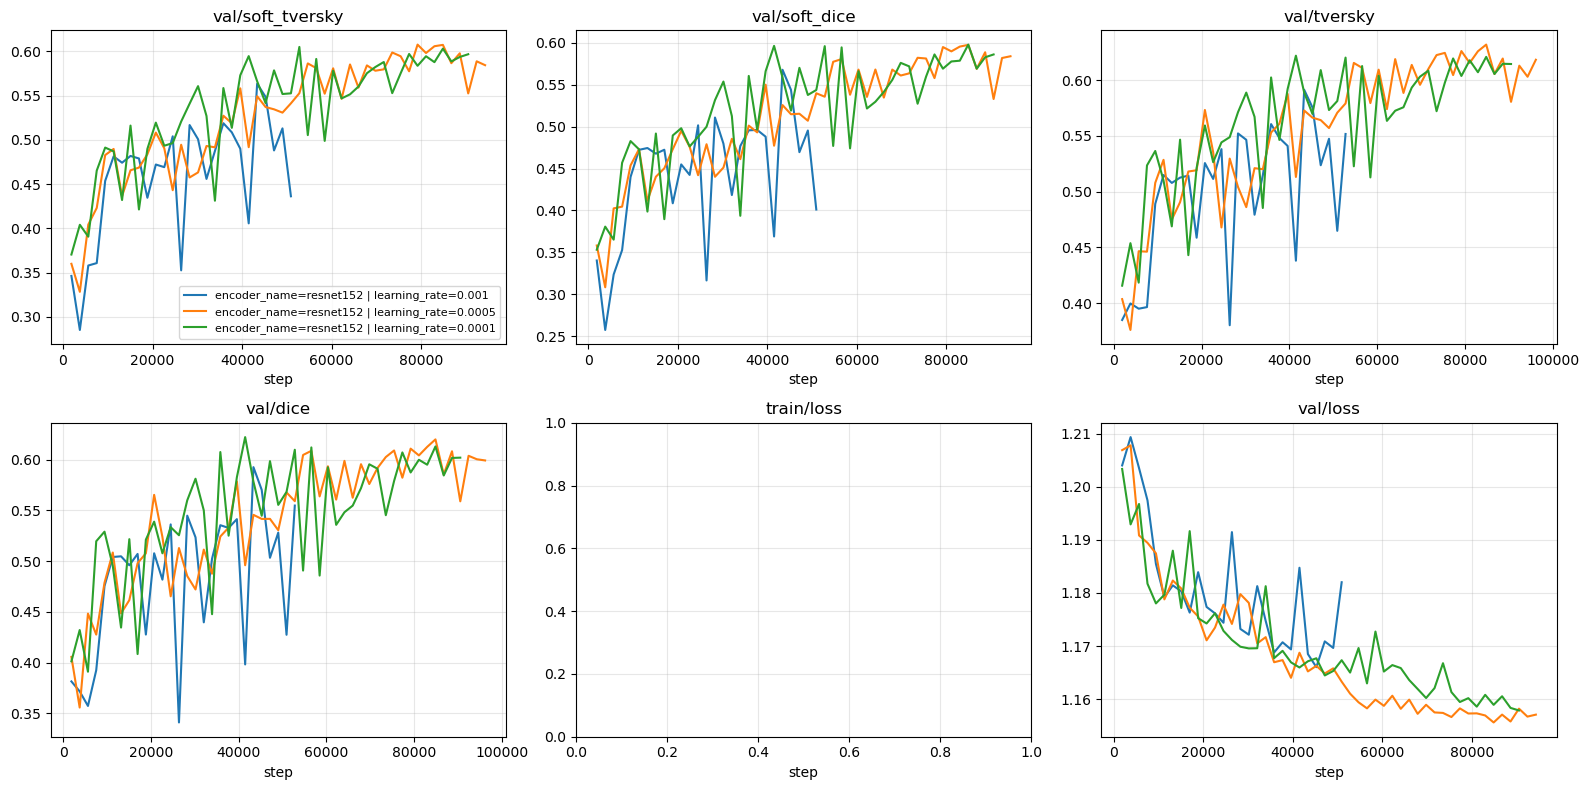

In [4]:
METRICS = [
    "val/soft_tversky",
    "val/soft_dice",
    "val/tversky",
    "val/dice",
    "train/loss",
    "val/loss",
]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))

for ax, metric_key in zip(axes.flat, METRICS):
    for run in runs:
        history = client.get_metric_history(run.info.run_id, metric_key)
        if not history:
            continue
        history.sort(key=lambda m: m.step)
        steps = [m.step for m in history]
        values = [m.value for m in history]
        ax.plot(steps, values, label=run.info.run_name or run.info.run_id)
    ax.set_title(metric_key)
    ax.set_xlabel("step")
    ax.grid(True, alpha=0.3)

axes.flat[0].legend(fontsize=8)
fig.tight_layout()
plt.show()

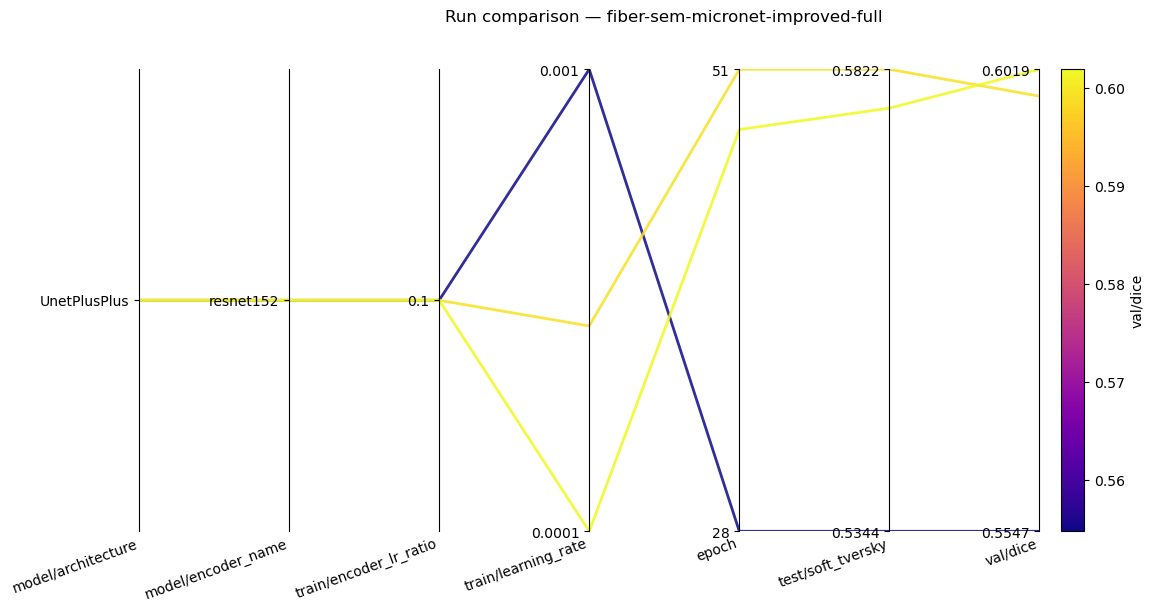

In [5]:
import numpy as np

# Parallel-coordinates comparison, like MLflow's own "Compare Runs" view:
# each column gets its OWN vertical axis (via host.twinx() per column) with
# its own tick marks/labels, all sharing one 0-1 drawing scale so the lines
# connect correctly; the outer plot box is removed, leaving only the
# per-column axis lines.
PC_COLUMNS = SUMMARY_COLUMNS[1:]  # everything except run_name
COLOR_COLUMN = "val/dice"
n = len(PC_COLUMNS)


def _axis_positions(col: str):
    values = summary_df[col]
    if pd.api.types.is_numeric_dtype(values):
        vmin, vmax = values.min(), values.max()
        if vmin == vmax:
            return {v: 0.5 for v in values}, [(vmin, 0.5)]
        norm_map = {v: (v - vmin) / (vmax - vmin) for v in values}
        return norm_map, [(vmin, 0.0), (vmax, 1.0)]
    uniques = list(pd.unique(values))
    if len(uniques) == 1:
        return {uniques[0]: 0.5}, [(uniques[0], 0.5)]
    norm_map = {u: i / (len(uniques) - 1) for i, u in enumerate(uniques)}
    return norm_map, [(u, i / (len(uniques) - 1)) for i, u in enumerate(uniques)]


norm_maps, tick_info = {}, {}
for col in PC_COLUMNS:
    norm_maps[col], tick_info[col] = _axis_positions(col)

color_values = summary_df[COLOR_COLUMN].astype(float)
cmap = plt.cm.plasma
color_norm = plt.Normalize(vmin=color_values.min(), vmax=color_values.max())

fig, host = plt.subplots(figsize=(14, 6))
axes_list = [host] + [host.twinx() for _ in range(n - 1)]
x_positions = list(range(n))

for i, (ax, col) in enumerate(zip(axes_list, PC_COLUMNS)):
    ax.set_ylim(0, 1)
    positions = [y for _, y in tick_info[col]]
    labels = [
        f"{val:.4g}" if isinstance(val, (int, float, np.floating)) else str(val)
        for val, _ in tick_info[col]
    ]
    ax.set_yticks(positions)
    ax.set_yticklabels(labels)
    ax.spines["left"].set_position(("axes", i / (n - 1) if n > 1 else 0))
    ax.spines["left"].set_visible(True)
    ax.yaxis.set_ticks_position("left")
    ax.yaxis.set_label_position("left")
    for spine in ("top", "right", "bottom"):
        ax.spines[spine].set_visible(False)
    ax.xaxis.set_visible(i == 0)

for _, row in summary_df.iterrows():
    ys = [norm_maps[col][row[col]] for col in PC_COLUMNS]
    host.plot(x_positions, ys, color=cmap(color_norm(row[COLOR_COLUMN])), linewidth=2, alpha=0.85)

host.set_xlim(0, n - 1)
host.set_xticks(x_positions)
host.set_xticklabels(PC_COLUMNS, rotation=20, ha="right")
host.tick_params(axis="x", length=0)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=color_norm)
sm.set_array([])
fig.colorbar(sm, ax=host, label=COLOR_COLUMN, pad=0.02)

fig.suptitle(f"Run comparison — {EXPERIMENT_NAME}")
plt.show()